In [2]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

In [3]:
from satellite_RFI.src.satellite_sims import satellite_sim as ss
import time
import pickle
import astropy.units as u
from datetime import datetime
import tqdm
import os


import scipy as sp
import numpy as np
import pandas as pd
import scipy.optimize as opt
import matplotlib.pyplot as plt

In [4]:
obs_time_input=None#'2021 9 30 20 06 36'
# fname = '1554156377'
fname = '1551055211'


"""
Establishing the file name
"""
if obs_time_input!=None:
    obs_time_in=[int(x) for x in obs_time_input.split()]
    obs_time = datetime(obs_time_in[0], obs_time_in[1], obs_time_in[2], obs_time_in[3], obs_time_in[4], obs_time_in[5])
    dt = obs_time.strftime('%Y-%m-%d %H:%M:%S')
    fname = int((obs_time - datetime(1970, 1, 1)).total_seconds())
    print ("File name to be used is: "+str(fname))

else:
    print ("File name to be used is: "+str(fname))
    dt = (datetime.utcfromtimestamp(float(fname)).strftime('%Y-%m-%d %H:%M:%S'))
    print ("Date of observation date: "+str(dt))


##   
    
katdal_info = pickle.load(open('/idia/projects/hi_im/brandon/1551055211/'+str(fname)+'_katdal_info.p', 'rb'), encoding='latin1')



info = [katdal_info[i] for i in katdal_info.keys()]

nd_s0=katdal_info['nd_s0']
nd_s0_coords=katdal_info['nd_s0_coords']
frequency=katdal_info['frequency']
fs=1000
fe=1500

data_save='data_test/'+str(fname)+'/pickle_info/'
if os.path.exists(data_save)==False:
    os.mkdir(data_save)
    
data_mkat = '../../../Observation_results/Untangle/'+str(fname)+'/'
nearby_constellation_path = 'nearby_cons_time_idx.p'

folder = '2022_02_28'


File name to be used is: 1551055211
Date of observation date: 2019-02-25 00:40:11


In [5]:
cons = ['GPS', 'SBAS', 'GAL', 'BDS', 'GLO', 'IRNSS']
bias = np.ones(len(cons))
sat = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc=data_mkat,
            survey_info=[nd_s0, nd_s0_coords, frequency], sat_info='../Satellite_simulations/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2.csv',
            plots_loc='data_test_plots/'+str(fname)+'/'+folder+'/',
            sat_beam='emss_beam_r', frequency_range=[1000,1500], constellations=cons, nearby_satellites=nearby_constellation_path)


In [5]:
num = 'chunk_'+str(12)
chunk_file = pickle.load(open('data_test/'+str(fname)+'/data_info/parallel_'+folder+'/data_test_'+num+'.p', 'rb'))
bsize = 100

In [6]:
sat.excecute(a_param=chunk_file['best-fit'], obs_time_start=chunk_file['time'][0], obs_time_end=chunk_file['time'][-1], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=bias, add_sub=[1, 1], band_lvl=[None, None], bandsize=None)

In [7]:
masked_sim_sat = np.ma.array(data=sat.simulation_TOD_slice, mask=sat.mask_nearby_satellites_slice.T)
masked_data_sat = np.ma.array(data=sat.calibration_data_slice, mask=sat.mask_nearby_satellites_slice.T)

#### Masked array

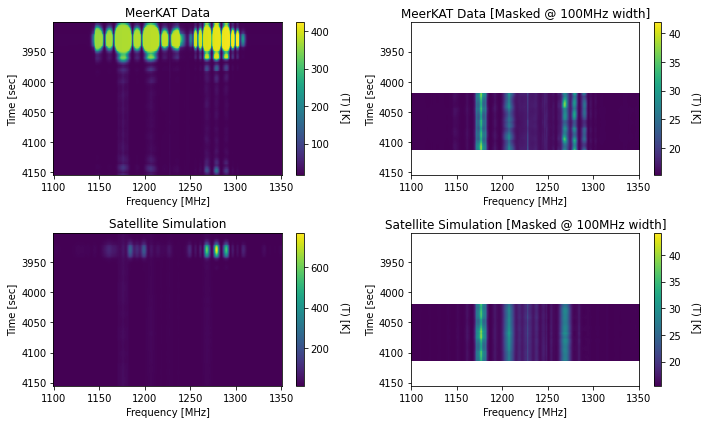

In [8]:
extent = [sat.frequency_band[sat.frequency_idx[0]], sat.frequency_band[sat.frequency_idx[1]],\
            sat.nd_s0[sat.time_idx[1]], sat.nd_s0[sat.time_idx[0]]]


fig, axs = plt.subplots(2, 2, figsize=(10,6))
fig.subplots_adjust(hspace=0.2)

ax = axs[0,0]
hb = ax.imshow((sat.calibration_data_slice.T), aspect='auto', extent=extent)
cbar = plt.colorbar(hb,ax=ax)
cbar.set_label(r'(T) [K]', rotation=270, labelpad=20, y=0.45)
ax.set_ylabel('Time [sec]')
ax.set_xlabel('Frequency [MHz]')
ax.set_title('MeerKAT Data')

ax = axs[0,1]
hb = ax.imshow((masked_data_sat.T), aspect='auto', extent=extent)
cbar = plt.colorbar(hb,ax=ax)
cbar.set_label(r'(T) [K]', rotation=270, labelpad=20, y=0.45)
ax.set_ylabel('Time [sec]')
ax.set_xlabel('Frequency [MHz]')
ax.set_title('MeerKAT Data [Masked @ '+str(bsize)+'MHz width]')

ax = axs[1,0]
hb = ax.imshow((sat.simulation_TOD_slice.T), aspect='auto', extent=extent)
cbar = plt.colorbar(hb,ax=ax)
cbar.set_label(r'(T) [K]', rotation=270, labelpad=20, y=0.45)
ax.set_ylabel('Time [sec]')
ax.set_xlabel('Frequency [MHz]')
ax.set_title('Satellite Simulation')

ax = axs[1,1]
hb = ax.imshow((masked_sim_sat.T), aspect='auto', extent=extent)
cbar = plt.colorbar(hb,ax=ax)
cbar.set_label(r'(T) [K]', rotation=270, labelpad=20, y=0.45)
ax.set_ylabel('Time [sec]')
ax.set_xlabel('Frequency [MHz]')
ax.set_title('Satellite Simulation [Masked @ '+str(bsize)+'MHz width]')

plt.tight_layout()
# plt.savefig('data_test_plots/1551055211/2022_03_09/masked_compare_'+num+'_f'+str(bsize)+'.png')

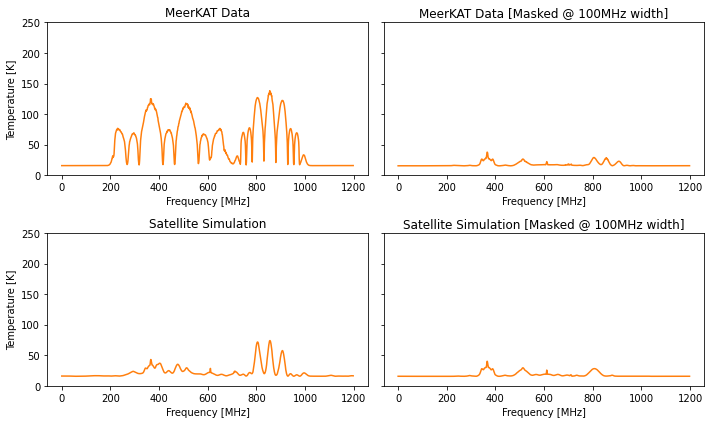

In [9]:
extent = [sat.frequency_band[sat.frequency_idx[0]], sat.frequency_band[sat.frequency_idx[1]],\
            sat.nd_s0[sat.time_idx[1]], sat.nd_s0[sat.time_idx[0]]]


fig, axs = plt.subplots(2, 2, figsize=(10,6), sharey=True)
fig.subplots_adjust(hspace=0.2)

ax = axs[0,0]
ax.plot(sat.frequency_band[sat.frequency_idx[0]], sat.frequency_band[sat.frequency_idx[1]], np.mean(sat.calibration_data_slice.T, axis=0))

ax.set_ylabel('Temperature [K]')
ax.set_xlabel('Frequency [MHz]')
ax.set_title('MeerKAT Data')


ax = axs[0,1]
ax.plot(sat.frequency_band[sat.frequency_idx[0]], sat.frequency_band[sat.frequency_idx[1]], np.mean(masked_data_sat.T, axis=0))

ax.set_xlabel('Frequency [MHz]')
ax.set_title('MeerKAT Data [Masked @ '+str(bsize)+'MHz width]')

ax = axs[1,0]
ax.plot(sat.frequency_band[sat.frequency_idx[0]], sat.frequency_band[sat.frequency_idx[1]], np.mean(sat.simulation_TOD_slice.T, axis=0))

ax.set_ylabel('Temperature [K]')
ax.set_xlabel('Frequency [MHz]')
ax.set_title('Satellite Simulation')

ax = axs[1,1]
ax.plot(sat.frequency_band[sat.frequency_idx[0]], sat.frequency_band[sat.frequency_idx[1]], np.mean(masked_sim_sat.T, axis=0))

ax.set_xlabel('Frequency [MHz]')
ax.set_title('Satellite Simulation [Masked @ '+str(bsize)+'MHz width]')


ax.set_ylim(0,250)
plt.tight_layout()
# plt.savefig('data_test_plots/1551055211/2022_03_09/masked_compare_1D_'+num+'_f'+str(bsize)+'.png')

#### SED

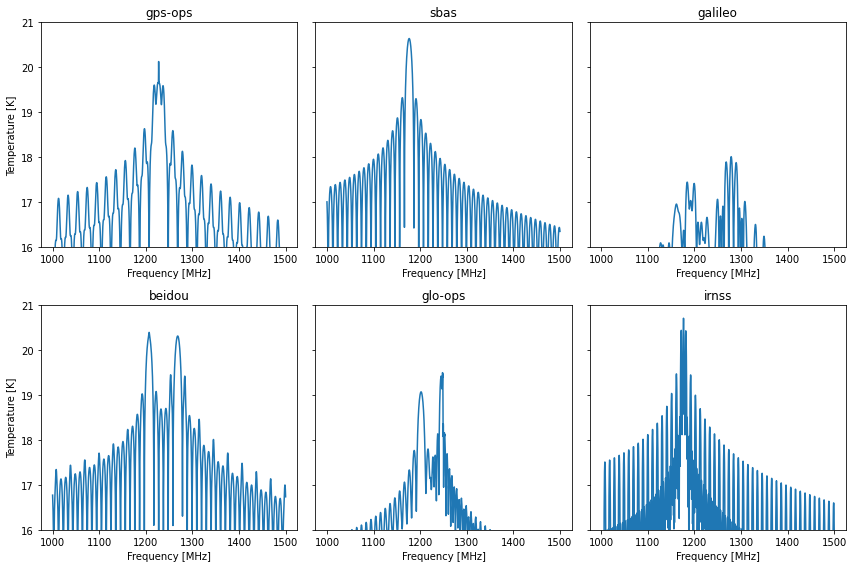

In [10]:

fig, axs = plt.subplots(2, 3, figsize=(12,8), sharey=True)
fig.subplots_adjust(hspace=0.2)

ax = axs[0,0]
ax.plot(sat.frequency_band, np.log10(sat.satellite_SED[0]))
ax.set_ylabel('Temperature [K]')
ax.set_xlabel('Frequency [MHz]')
ax.set_title(sat.satellite_type[0])
ax = axs[0,1]
ax.plot(sat.frequency_band, np.log10(sat.satellite_SED[1]))
ax.set_xlabel('Frequency [MHz]')
ax.set_title(sat.satellite_type[1])
ax = axs[0,2]
ax.plot(sat.frequency_band, np.log10(sat.satellite_SED[2]))
ax.set_xlabel('Frequency [MHz]')
ax.set_title(sat.satellite_type[2])
ax = axs[1,0]
ax.plot(sat.frequency_band, np.log10(sat.satellite_SED[3]))
ax.set_ylabel('Temperature [K]')
ax.set_xlabel('Frequency [MHz]')
ax.set_title(sat.satellite_type[3])
ax = axs[1,1]
ax.plot(sat.frequency_band, np.log10(sat.satellite_SED[4]))
ax.set_xlabel('Frequency [MHz]')
ax.set_title(sat.satellite_type[4])
ax = axs[1,2]
ax.plot(sat.frequency_band, np.log10(sat.satellite_SED[5]))
ax.set_xlabel('Frequency [MHz]')
ax.set_title(sat.satellite_type[5])
ax.set_ylim(16,21)
plt.tight_layout()
# plt.savefig('data_test_plots/1551055211/2022_03_09/masked_compare_1D_'+num+'_f'+str(bsize)+'.png')

#### on alpha parameters

### Testing the ability to retrieve a simulated result

In [ ]:
cons = ['GPS', 'SBAS', 'GAL', 'BDS', 'GLO', 'IRNSS']
bias = np.ones(len(cons))


In [ ]:
sat = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc=data_mkat,
            survey_info=[nd_s0, nd_s0_coords, frequency], sat_info='../Satellite_simulations/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2.csv',
            plots_loc='data_test_plots/'+str(fname)+'/'+folder+'/',
            sat_beam='emss_beam_r', frequency_range=[1000,1500], constellations=cons)


### -------------------------------------------------------------------------------------------------

### Alpha Plot

Plots the Alpha values for different chunks or data sets.\\\\
Also links to the plotting the sat_sim code

In [16]:
def alpha_plot(fname, num, chunk):
    '''
    fname-file name
    num-which number you are on
    chunk-the dictionary associated with the num
    '''
    
    
    plt.figure(figsize=(10,4))
    plt.plot(chunk['initial'], 'b.', label='Initial point')
    plt.plot(chunk['initial'], 'b-')
    plt.plot(chunk['best-fit'], 'g.', label='Best-fit')
    plt.plot(chunk['best-fit'], 'g-')

    plt.xlabel('# of alpha')
    plt.ylabel('Value [constant]')

    time = str(np.round(chunk['time'][0],2))+'-'+str(np.round(chunk['time'][-1],2))
    plt.title('Time chunk: '+time)

    textstr = '\n'.join((
        r'$\chi^2_{'+str(num)+'}=%.2f$' % (chunk['chi2_value'], ),
        r'$\dfrac{\chi^2_{'+str(num)+'}}{N}=%.2f$' % (chunk['chi2_div'], )

    ))

    plt.text(22, 2, textstr, verticalalignment='top')

    plt.legend(bbox_to_anchor=[1.2, 1], loc='upper right')
    plt.tight_layout()
#     plt.savefig('data_test_plots/'+str(fname)+'/'+folder+'/'+str(fname)+'_data_test_alpha'+str(num)+'.png')
#     plt.show()




In [ ]:
path = 'data_test/'+fname+'/data_info/.p'

for chunk_i in range(0,22):
    num = 'chunk_'+str(chunk_i)
    chunk_file = pickle.load(open('data_test/'+str(fname)+'/data_info/parallel_'+folder+'/data_test_'+num+'.p', 'rb'))

    print (chunk_i, '\t', np.round(chunk_file['chi2_value'],2), '\t', np.round(chunk_file['chi2_div'],2))
    alpha_plot(fname=fname, num=chunk_i, chunk=chunk_file)

    sat.excecute(a_param=chunk_file['best-fit'], obs_time_start=chunk_file['time'][0], obs_time_end=chunk_file['time'][-1], obs_frequency_start=1100, obs_frequency_end=1350, 
                file_bias_choice=bias, add_sub=[1, 1], band_lvl=[None, None])

    sat.plotting(individual=None, logger=1, axis_limit=[None, None, None, None], tod_limit=None, save_file=None, file_type='png')


### -------------------------------------------------------------------------------------------------

In [ ]:
data_11 = pickle.load(open('data_test/1551055211/data_info/parallel_'+folder+'/data_test_chunk_11.p', 'rb'))
chunk_i = 11

In [ ]:
sat.excecute(a_param=data_11['best-fit'], obs_time_start=nd_s0[chunk_i*100], obs_time_end=nd_s0[chunk_i*100+100], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=bias, add_sub=[1, 1], band_lvl=[None, None])


In [ ]:
extent = [sat.frequency_band[sat.frequency_idx[0]], sat.frequency_band[sat.frequency_idx[1]],\
            sat.nd_s0[sat.time_idx[1]], sat.nd_s0[sat.time_idx[0]]]


fig, ax = plt.subplots(1, 3, figsize=(18,4))
fig.subplots_adjust(hspace=0)

ax0 = ax[0]

hb = ax0.imshow(np.log10(sat.calibration_data_slice.T), aspect='auto', extent=extent)
cbar = plt.colorbar(hb,ax=ax0)
cbar.set_label(r'log$_{10}$(T) [K]', rotation=270, labelpad=20, y=0.45)
ax0.set_ylabel('Time [sec]')
ax0.set_xlabel('Frequency [MHz]')
ax0.set_title('MeerKAT Data')
# plt.title('Chunk 11: '+str(np.round(sat.nd_s0[sat.time_idx[0]],2))+'-'+str(np.round(sat.nd_s0[sat.time_idx[1]],2))+' sec')

ax1 = ax[1]
hb = ax1.imshow(np.log10(sat.simulation_TOD_slice.T), aspect='auto', extent=extent)
cbar = plt.colorbar(hb,ax=ax1)
cbar.set_label(r'log$_{10}$(T) [K]', rotation=270, labelpad=20, y=0.45)
ax1.set_ylabel('Time [sec]')
ax1.set_xlabel('Frequency [MHz]')
ax1.set_title('Satellite Simulation')

ax2 = ax[2]
hb = ax2.imshow(((sat.calibration_data_slice.T - sat.simulation_TOD_slice.T)/sat.calibration_data_slice.T), aspect='auto', extent=extent)
cbar = plt.colorbar(hb,ax=ax2)
cbar.set_label(r'$\dfrac{T_{data}-T_{sim}}{T_{data}}$', rotation=270, labelpad=20, y=0.45)
ax2.set_ylabel('Time [sec]')
ax2.set_xlabel('Frequency [MHz]')
ax2.set_title('Fractional difference')


plt.tight_layout()
# plt.savefig('data_test_plots/1551055211/'+folder+'/chunk_11_waterfall.png')
plt.show()

In [ ]:
freqs = sat.frequency_band[sat.frequency_idx[0]:sat.frequency_idx[1]]
time  = sat.nd_s0[sat.time_idx[0]:sat.time_idx[1]]

split_cali_11 = np.array_split(sat.calibration_data_slice.T, 10, axis=0)
split_sim_11 = np.array_split(sat.simulation_TOD_slice.T, 10, axis=0)

time_11_split = np.array_split(np.round(nd_s0[chunk_i*100:chunk_i*100+100],2), 10)

In [ ]:
for split_i in range(10):

    fig, ax = plt.subplots(2, 1, figsize=(8,6), sharex=True)
    fig.subplots_adjust(hspace=0)

    ax0=ax[0]
    ax0.set_title('Chunk 11: '+str(time_11_split[split_i][0])+'-'+str(time_11_split[split_i][-1])+' sec')
    ax0.plot(freqs,np.mean(split_cali_11[split_i], axis=0), label='MeerKAT data')
    ax0.plot(freqs,np.mean(split_sim_11[split_i], axis=0), label='Satellite simulation')
    ax0.set_ylabel('Tempreture [K]')
    ax0.legend()

    ax1=ax[1]
    ax1.plot(freqs,(np.mean(split_cali_11[split_i],axis=0) - np.mean(split_sim_11[split_i], axis=0))/np.mean(split_cali_11[split_i],axis=0), label=r'% difference')
    ax1.set_ylabel(r'$\dfrac{T_{data}-T_{sim}}{T_{data}}$ ')
    ax1.set_xlabel('Frequency [MHz]')
    ax1.legend()

    fig.tight_layout()
#     plt.savefig('data_test_plots/1551055211/'+folder+'/chunk_11_'+str(split_i)+'.png')

In [ ]:

def freq_slice(f_val):
    f = np.where(freqs>f_val)[0][0]


    plt.plot(time, sat.calibration_data_slice[f,:], label='MeerKAT data')
    plt.plot(time, sat.simulation_TOD_slice[f,:], label='Satellite simulation')
    plt.ylabel('Tempreture [K]')
    plt.xlabel('Time [sec]')
    plt.title('Frequency slice @ '+str(freqs[f])+' MHz')

    plt.legend(loc='upper left')
    plt.tight_layout()
#     plt.savefig('data_test_plots/1551055211/'+folder+'/chunk_11_freq_'+str(freqs[f])+'.png')
    plt.show()

In [ ]:
fval = [1148, 1275, 1210, 1250, 1175, 1300]
for f in fval:
    freq_slice(f_val=f)

### Single Galileo satellite

In [ ]:
consg = ['GAL']
biasg = np.ones(len(consg))

In [ ]:
satg = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc=data_mkat,
            survey_info=[nd_s0, nd_s0_coords, frequency], sat_info='../Satellite_simulations/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2.csv',
            plots_loc='data_test_plots/'+str(fname)+'/'+folder+'/',
            sat_beam='emss_r_gal1', frequency_range=[1000,1500], constellations=consg, verbose=True)


In [ ]:
chunk_i = 11

num = 'chunk_'+str(chunk_i)
chunk_file = pickle.load(open('data_test/'+str(fname)+'/data_info/parallel_'+folder+'/data_test_'+num+'.p', 'rb'))

In [ ]:
satg_alpha = np.array([0,0,0,1])
# print (satg_alpha)


In [ ]:
chunk_file['best-fit'][15:19]

In [ ]:
satg.excecute(a_param=chunk_file['best-fit'][15:19], obs_time_start=chunk_file['time'][0], obs_time_end=chunk_file['time'][-1], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=biasg, add_sub=[1, 1], band_lvl=[None, None])

In [ ]:
satg.fre

In [ ]:
extent = [sat.frequency_band[0], sat.frequency_band[-1],\
            sat.nd_s0[-1], sat.nd_s0[0]]



hb=plt.imshow(np.log10(satg.get_satellite_angle_seperation()[1][0].T), aspect='auto', extent=extent)
plt.colorbar(hb)
plt.title('Single galileo satellite')
plt.xlabel('Frequency [MHz]')
plt.ylabel('Time [sec]')

In [ ]:
gal_beam = pickle.load(open('../../../Observation_results/Untangle/1551055211/1551055211_satellite_angular_position_emss_r_gal_1.p', 'rb'), encoding='latin1')['angular'][0]

gal_beam_slice = gal_beam[sat.frequency_idx[0]:sat.frequency_idx[1], sat.time_idx[0]:sat.time_idx[1]].T

In [ ]:
extent = [sat.frequency_band[sat.frequency_idx[0]], sat.frequency_band[sat.frequency_idx[1]],\
            sat.nd_s0[sat.time_idx[1]], sat.nd_s0[sat.time_idx[0]]]


plt.figure()
hb=plt.imshow(gal_beam_slice, aspect='auto', extent=extent)
plt.colorbar(hb)

plt.title('Single galileo satellite')
plt.xlabel('Frequency [MHz]')
plt.ylabel('Time [sec]')

plt.tight_layout()

#### Coarse Grainer

In [ ]:
def coarse_grainer(array, coarseness):
    '''
    Function to take a 2d array and increase the coarse level of it
    array - 2D map
    coarsness - coarse grain value
    # https://stackoverflow.com/questions/34689519/how-to-coarser-the-2-d-array-data-resolution
    '''
    shape = np.array(array.shape, dtype=int)
    new_shape = coarseness * np.ceil(shape / coarseness).astype(int)

    new_array = np.zeros(new_shape)
    new_array[:shape[0], :shape[1]] = array

    x = new_array.reshape((new_shape[0] // coarseness, coarseness,
                                   new_shape[1] // coarseness, coarseness))

    return np.mean(x, axis=(1,3))

In [ ]:
sim_coarse = coarse_grainer(array=satg.simulation_TOD_slice.T, coarseness=10)

data_coarse = coarse_grainer(array=satg.calibration_data_slice.T, coarseness=10)

In [ ]:
extent = [sat.frequency_band[sat.frequency_idx[0]], sat.frequency_band[sat.frequency_idx[1]],\
            sat.nd_s0[sat.time_idx[1]], sat.nd_s0[sat.time_idx[0]]]


fig, ax = plt.subplots(2, 2, figsize=(18,10))
fig.subplots_adjust(hspace=0)

ax0 = ax[0,0]
hb = ax0.imshow((satg.calibration_data_slice.T), aspect='auto', extent=extent)
cbar = plt.colorbar(hb,ax=ax0)
cbar.set_label(r'(T) [K]', rotation=270, labelpad=20, y=0.45)
ax0.set_ylabel('Time [sec]')
ax0.set_xlabel('Frequency [MHz]')
ax0.set_title('MeerKAT Data (Fine)')
# plt.title('Chunk 11: '+str(np.round(sat.nd_s0[sat.time_idx[0]],2))+'-'+str(np.round(sat.nd_s0[sat.time_idx[1]],2))+' sec')

ax1 = ax[0,1]
hb = ax1.imshow((satg.simulation_TOD_slice.T), aspect='auto', extent=extent)
cbar = plt.colorbar(hb,ax=ax1)
cbar.set_label(r'(T) [K]', rotation=270, labelpad=20, y=0.45)
ax1.set_ylabel('Time [sec]')
ax1.set_xlabel('Frequency [MHz]')
ax1.set_title('Satellite Simulation (Fine)')

ax2 = ax[1,0]
hb = ax2.imshow((data_coarse), aspect='auto', extent=extent)
cbar = plt.colorbar(hb,ax=ax2)
cbar.set_label(r'(T) [K]', rotation=270, labelpad=20, y=0.45)
ax2.set_ylabel('Time [sec]')
ax2.set_xlabel('Frequency [MHz]')
ax2.set_title('MeerKAT Data (Coarse)')
# plt.title('Chunk 11: '+str(np.round(sat.nd_s0[sat.time_idx[0]],2))+'-'+str(np.round(sat.nd_s0[sat.time_idx[1]],2))+' sec')

ax3 = ax[1,1]
hb = ax3.imshow((sim_coarse), aspect='auto', extent=extent)
cbar = plt.colorbar(hb,ax=ax3)
cbar.set_label(r'(T) [K]', rotation=270, labelpad=20, y=0.45)
ax3.set_ylabel('Time [sec]')
ax3.set_xlabel('Frequency [MHz]')
ax3.set_title('Satellite Simulation (Coarse)')


plt.tight_layout()
# plt.savefig('data_test_plots/1551055211/'+folder+'/chunk_11_waterfall.png')
plt.show()

In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(18,4))
fig.subplots_adjust(hspace=0)

ax0 = ax[0]
ax0.plot(freqs, np.mean(satg.calibration_data_slice.T, axis=0), label='MeerKAT data')
ax0.plot(freqs, np.mean(satg.simulation_TOD_slice.T, axis=0), label='Satellite simulation')
ax0.set_ylabel('Temperature [K]')
ax0.set_xlabel('Frequency [MHz]')
ax0.set_title('Fine gridding')


ax2 = ax[1]
ax2.plot(np.histogram_bin_edges(freqs, bins=119), np.mean(data_coarse, axis=0), label='MeerKAT data')
ax2.plot(np.histogram_bin_edges(freqs, bins=119), np.mean(sim_coarse, axis=0), label='Satellite simulation')

ax2.set_ylabel('Temperature [K]')
ax2.set_xlabel('Frequency [MHz]')
ax2.set_title('Coarse gridding')
# plt.title('Chunk 11: '+str(np.round(sat.nd_s0[sat.time_idx[0]],2))+'-'+str(np.round(sat.nd_s0[sat.time_idx[1]],2))+' sec')



# ax1.get_shared_y_axes().join(ax0, ax1)
# ax3.get_shared_y_axes().join(ax2, ax3)


plt.tight_layout()
plt.legend()
# plt.savefig('data_test_plots/1551055211/'+folder+'/chunk_11_waterfall.png')
plt.show()

In [ ]:
plt.title('Average over frequency')

plt.plot(nd_s0[satg.time_idx[0]:satg.time_idx[1]], np.mean(sat.calibration_data_slice.T, axis=1), label='MeerKAT data')
plt.plot(nd_s0[satg.time_idx[0]:satg.time_idx[1]], np.mean(sat.simulation_TOD_slice.T, axis=1), label='Satellite simulation')
plt.xlabel('Time [sec]')
plt.ylabel('Temperature [K]')
plt.legend()

In [ ]:
np.where(sat.calibration_data_slice==sat.calibration_data_slice.max())

In [ ]:
plt.title('Frequency @'+str(freqs[855])+' MHz')
plt.plot(nd_s0[satg.time_idx[0]:satg.time_idx[1]], sat.calibration_data_slice.T[:, 855], label='MeerKAT data')
plt.plot(nd_s0[satg.time_idx[0]:satg.time_idx[1]], sat.simulation_TOD_slice.T[:,855], label='Satellite simulation')
plt.xlabel('Time [sec]')
plt.ylabel('Temperature [K]')
plt.legend()